# Projet Machine Learning : Prédiction du spread souverain via les news

## 1. Données

### 1.1 Chargement des packages

In [29]:
%pip install pandas numpy requests pandas_datareader gdeltdoc scikit-learn feedparser

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6048 sha256=794960ca9990d12f87129bb45db6f53c74f16fb1ace50cd4d8a01c5c00bf2d0d
  Stored in directory: /Users/marion/Library/Caches/pip/wheels/83/63/2f/117884c3b19d46b64d3d61690333aa80c88dc14050e269c546
Successfully built sgmllib3k
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


### 1.2 Chargement des taux souverains

Cette partie nous a donné beaucoup de fil à retorde. En effet, afin de pratiquer le Machine Learning correctement, nous avions besoin d'un grand nombre de point. Ainsi, les séries quotiennes nous ont parru les plus pertinentes, car elles permettent d'avoir beaucoup de valeurs sans avoir une profondeur trop importante. 

Données sur les taux 10 Ans de la France et de l'Allemagne, calcul du spread et de la volatilité 
Source : 
    Pour la France : série "TEC10" : https://www.banque-france.fr/fr/statistiques/taux-et-cours/indices-obligataires-2026-03-02 
    Pour l'Allemagne : série "BBSSY.D.EUR.A615.000000WT1515.A" : https://www.bundesbank.de/en/statistics/money-and-capital-markets/interest-rates-and-yields/daily-yields-of-current-federal-securities-772220 

In [3]:
PATH_DATA = "../data/"

# -------------------------
# 1) France daily
# -------------------------
fr = pd.read_csv(
    PATH_DATA + "Webstat_Export_fr_5385693.csv",
    sep=";",
    skiprows=6,
    header=None
)

# on garde : date + colonne du 10 ans français
fr = fr.iloc[:, [0, 2]]
fr.columns = ["date", "fr_10y"]

fr["date"] = pd.to_datetime(fr["date"], errors="coerce")
fr["fr_10y"] = (
    fr["fr_10y"]
    .replace("-", pd.NA)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
fr["fr_10y"] = pd.to_numeric(fr["fr_10y"], errors="coerce")

# -------------------------
# 2) Allemagne daily
# -------------------------
de = pd.read_csv(PATH_DATA + "BBSSY.D.REN.EUR.A630.000000WT1010.A.csv")

de = de.iloc[:, [0, 1]]
de.columns = ["date", "de_10y"]

de["date"] = pd.to_datetime(de["date"], errors="coerce")
de["de_10y"] = pd.to_numeric(de["de_10y"], errors="coerce")

/var/folders/d4/16452hgn1nq8q_prgj63b1_w0000gn/T/ipykernel_37442/2195060014.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  de["date"] = pd.to_datetime(de["date"], errors="coerce")


### 1.3 Construction du spread

In [4]:
# -------------------------
# 1) Merge + spread daily
# -------------------------
spread = pd.merge(fr, de, on="date", how="inner").sort_values("date")

spread["spread"] = spread["fr_10y"] - spread["de_10y"]

spread = spread.set_index("date")

spread.head()

# -------------------------
# 2) Delta et Volatilité
# -------------------------

spread = spread.dropna(subset=["spread"]) # Supprime les données manquantes, notamment WE et jours fériés

spread["delta"] = spread["spread"].diff()
spread.head()

spread["direction"] = (spread["delta"] > 0).astype(int)
spread.head()

spread["vol_1m"] = spread["delta"].rolling(22).std() # sur un mois glissant
spread["vol_1w"] = spread["delta"].rolling(5).std() # sur une semaine (de bourse) glissante

# -------------------------
# 3) Visualisation et commentaires
# -------------------------

print(spread.head(100))
print(spread["direction"].value_counts(normalize=True)) # On constate 2 classes relativement équilibrées (55% de 0 contre 45% de 1)

            fr_10y  de_10y  spread         delta  direction    vol_1m  \
date                                                                    
2004-11-03    3.97    3.91    0.06           NaN          0       NaN   
2004-11-04    3.93    3.87    0.06  0.000000e+00          0       NaN   
2004-11-05    3.91    3.85    0.06  0.000000e+00          0       NaN   
2004-11-08    3.96    3.90    0.06  0.000000e+00          0       NaN   
2004-11-09    3.95    3.89    0.06  0.000000e+00          0       NaN   
...            ...     ...     ...           ...        ...       ...   
2005-03-18    3.72    3.69    0.03  4.440892e-16          1  0.006530   
2005-03-21    3.76    3.73    0.03 -4.440892e-16          0  0.006530   
2005-03-22    3.74    3.70    0.04  1.000000e-02          1  0.006838   
2005-03-23    3.76    3.73    0.03 -1.000000e-02          0  0.007222   
2005-03-24    3.75    3.72    0.03  0.000000e+00          0  0.007222   

                  vol_1w  
date                   

### 1.4 Graphique Spread

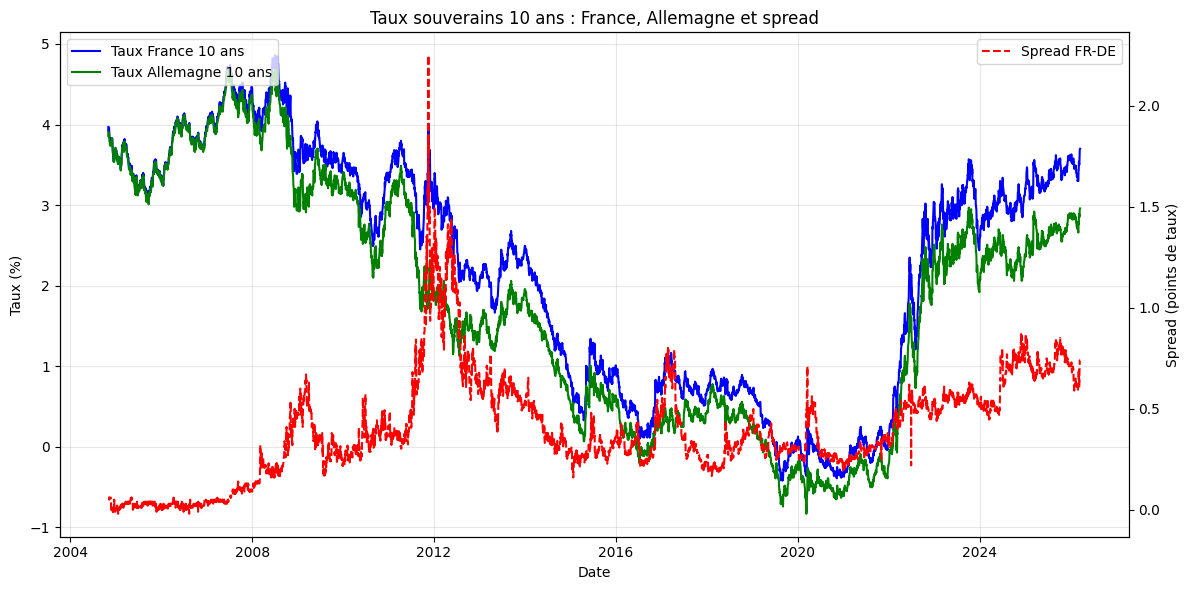

In [5]:
# graphique 1 : Spread 
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(spread.index, spread["fr_10y"], label="Taux France 10 ans", color="blue")
ax1.plot(spread.index, spread["de_10y"], label="Taux Allemagne 10 ans", color="green")
ax1.set_xlabel("Date")
ax1.set_ylabel("Taux (%)")
ax1.set_title("Taux souverains 10 ans : France, Allemagne et spread")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(spread.index, spread["spread"], linestyle="--", label="Spread FR-DE", color="red")
ax2.set_ylabel("Spread (points de taux)")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 1.5 Graphique Volatilité glissante du Spread

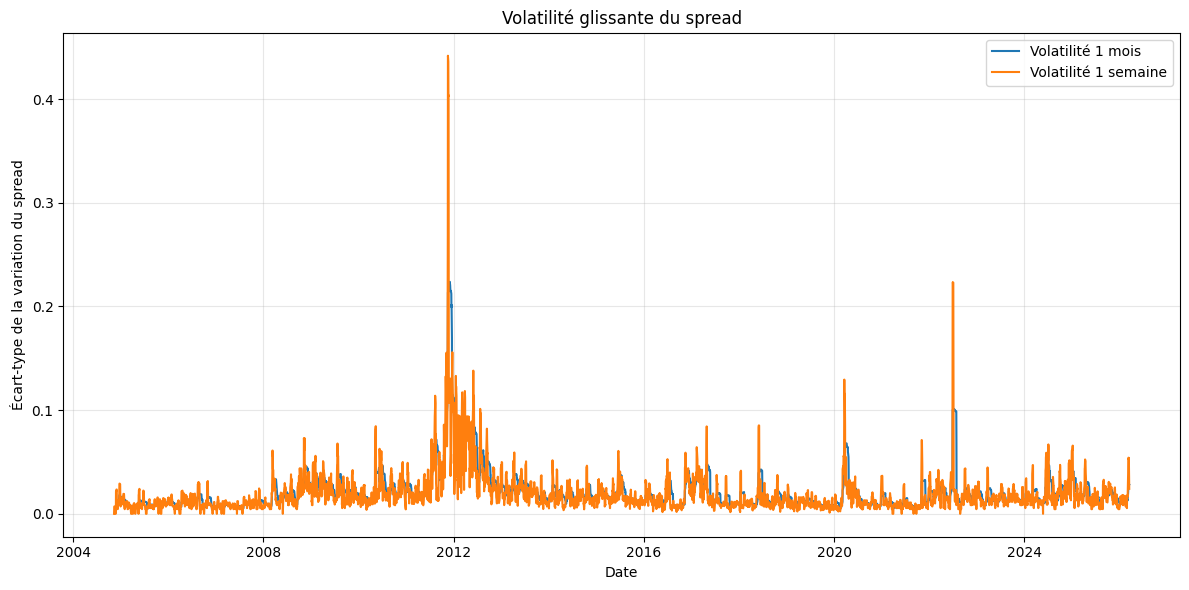

In [6]:
#Graphique 2 : Vol
plt.figure(figsize=(12, 6))
plt.plot(spread.index, spread["vol_1m"], label="Volatilité 1 mois")
plt.plot(spread.index, spread["vol_1w"], label="Volatilité 1 semaine")
plt.title("Volatilité glissante du spread")
plt.xlabel("Date")
plt.ylabel("Écart-type de la variation du spread")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6 Version hebdomadaire (vendredi)

            spread  delta_w  direction_w
date                                    
2004-11-05    0.06      NaN            0
2004-11-12    0.06     0.00            0
2004-11-19    0.06     0.00            0
2004-11-26    0.00    -0.06            0
2004-12-03    0.00     0.00            0
2004-12-10    0.00     0.00            0
2004-12-17    0.01     0.01            1
2004-12-24    0.00    -0.01            0
2004-12-31    0.00     0.00            0
2005-01-07    0.01     0.01            1


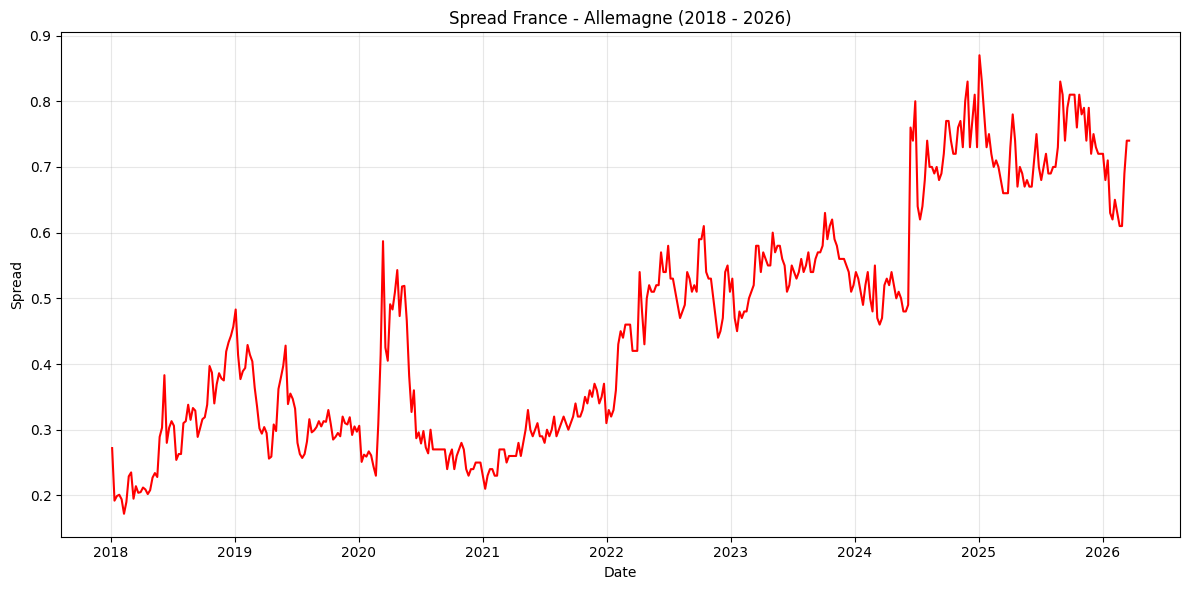

In [7]:
spread_weekly = spread.resample("W-FRI").last()

# delta hebdo
spread_weekly["delta_w"] = spread_weekly["spread"].diff()

# direction hebdo
spread_weekly["direction_w"] = (spread_weekly["delta_w"] > 0).astype(int)

# aperçu
print(spread_weekly[["spread", "delta_w", "direction_w"]].head(10))

spread_w_2018_2026 = spread_weekly.loc["2018":"2026"]

# Graphique Spread France - Allemagne
plt.figure(figsize=(12, 6))
plt.plot(spread_w_2018_2026.index, spread_w_2018_2026["spread"], color="red")

plt.title("Spread France - Allemagne (2018 - 2026)")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Construction des features news : avec Reuters (partie 1)

→ Données relatives aux News et regression sur les spreads.<br>
Nous avons exploré différentes sources, en français ou en anglais, avec des profondeurs plus ou moins grandes et des précisions plus ou moins importantes.<br>
Plusieurs obstacles se sont dressés contre nous : d'abord, la plupart des bases sont payantes, ou alors ne permettent pas d'avoir suffisament de points pour faire du ML.<br> De plus, comme vous allez le voir, les résultats sont malheureusement très peu significatifs. Nous avons testé un grand nombre d'outils et de set de données, en obtenant des resultats très peu probants, surement car la relation que l'on cherche à démontrer n'existe pas, ou est systématiquement pollué par les bruits de marché.<br>
Néanmois, nous nous sommes attachés à décrire les outils de ML utilisés et les résultats obtenus, même si ceci sont décevants sur le plan conceptuel. 

### 2.1 Reuters
L'agence de presse nous permet d'exploiter les titres et une brève description de ses dépêches. 
Gratuitement, nous n'avons pu récupéré que les données de 2018 à 2020 

#### 2.1.1 Chargement des données

In [8]:
# -------------------------
# 1) Chargement des données
# -------------------------
news_reuters_df = pd.read_csv("../data/reuters_headlines.csv")
news_reuters_df["Time"] = pd.to_datetime(news_reuters_df["Time"], errors="coerce")
min_date = news_reuters_df["Time"].min()
max_date = news_reuters_df["Time"].max()
print(f"Sample : {min_date.date()} - {max_date.date()}")
print(news_reuters_df.columns)
news_reuters_df.head()

Sample : 2018-03-20 - 2020-07-18
Index(['Headlines', 'Time', 'Description'], dtype='object')


,Headlines,Time,Description
0,TikTok considers London and other locations fo...,2020-07-18,TikTok has been in discussions with the UK gov...
1,Disney cuts ad spending on Facebook amid growi...,2020-07-18,Walt Disney has become the latest company to ...
2,Trail of missing Wirecard executive leads to B...,2020-07-18,Former Wirecard chief operating officer Jan M...
3,Twitter says attackers downloaded data from up...,2020-07-18,Twitter Inc said on Saturday that hackers were...
4,U.S. Republicans seek liability protections as...,2020-07-17,A battle in the U.S. Congress over a new coron...


#### 2.1.2 Construction des features

In [9]:
# -------------------------
# 2) Construction des features
# -------------------------

import re

# Construire le texte complet
news_reuters_df["text"] = (
    news_reuters_df["Headlines"].fillna("") + " " +
    news_reuters_df["Description"].fillna("")
)

news_reuters_df["text"] = news_reuters_df["text"].str.lower()

# Convertir la date/heure
news_reuters_df["Time"] = pd.to_datetime(news_reuters_df["Time"], errors="coerce")

# Date journalière compatible avec le spread
news_reuters_df["date"] = news_reuters_df["Time"].dt.normalize()

news_reuters_df["date"].min(), news_reuters_df["date"].max()

# --------------------------------------------------
# Listes de mots-clés macro
# --------------------------------------------------
inflation_words = [
    "inflation", "price pressure", "cpi", "hike",
    "rate increase", "monetary policy", "hawkish",
    "dovish", "tightening", "ecb"
]

risk_words = [
    "crisis", "recession", "debt", "deficit",
    "default", "downgrade", "risk premium",
    "volatility", "instability"
]

growth_words = [
    "recovery", "expansion", "gdp", "growth",
    "unemployment", "employment"
]

geopolitical_words = [
    "war", "conflict", "energy shock",
    "gas", "sanctions"
]

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

news_reuters_df["macro_inflation_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, inflation_words)
)

news_reuters_df["macro_risk_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, risk_words)
)

news_reuters_df["growth_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, growth_words)
)

news_reuters_df["geopolitical_index"] = news_reuters_df["text"].apply(
    lambda x: count_keywords(x, geopolitical_words)
)

# --------------------------------------------------
# Agrégation journalière
# --------------------------------------------------
daily_reuters_indices = news_reuters_df.groupby("date", as_index=False)[[
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]].sum()

daily_reuters_indices.head()

,date,macro_inflation_index,macro_risk_index,growth_index,geopolitical_index
0,2018-03-20,2,2,0,15
1,2018-03-21,13,2,2,9
2,2018-03-22,2,4,4,17
3,2018-03-23,5,1,4,12
4,2018-03-24,0,0,1,3


#### 2.1.3 Graphique

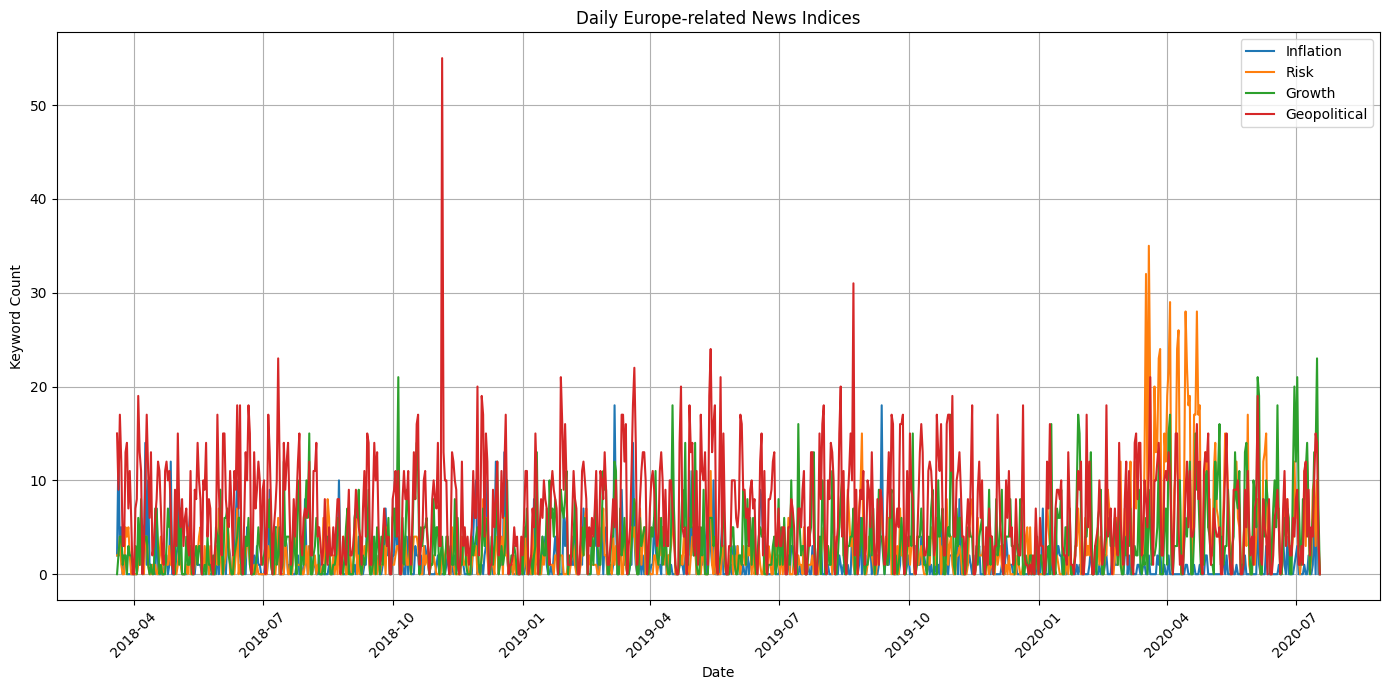

In [10]:
# --------------------------------------------------
# Visualisation des features
# --------------------------------------------------

plt.figure(figsize=(14, 7))

plt.plot(daily_reuters_indices["date"], daily_reuters_indices["macro_inflation_index"], label="Inflation")
plt.plot(daily_reuters_indices["date"], daily_reuters_indices["macro_risk_index"], label="Risk")
plt.plot(daily_reuters_indices["date"], daily_reuters_indices["growth_index"], label="Growth")
plt.plot(daily_reuters_indices["date"], daily_reuters_indices["geopolitical_index"], label="Geopolitical")

plt.title("Daily Europe-related News Indices")
plt.xlabel("Date")
plt.ylabel("Keyword Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

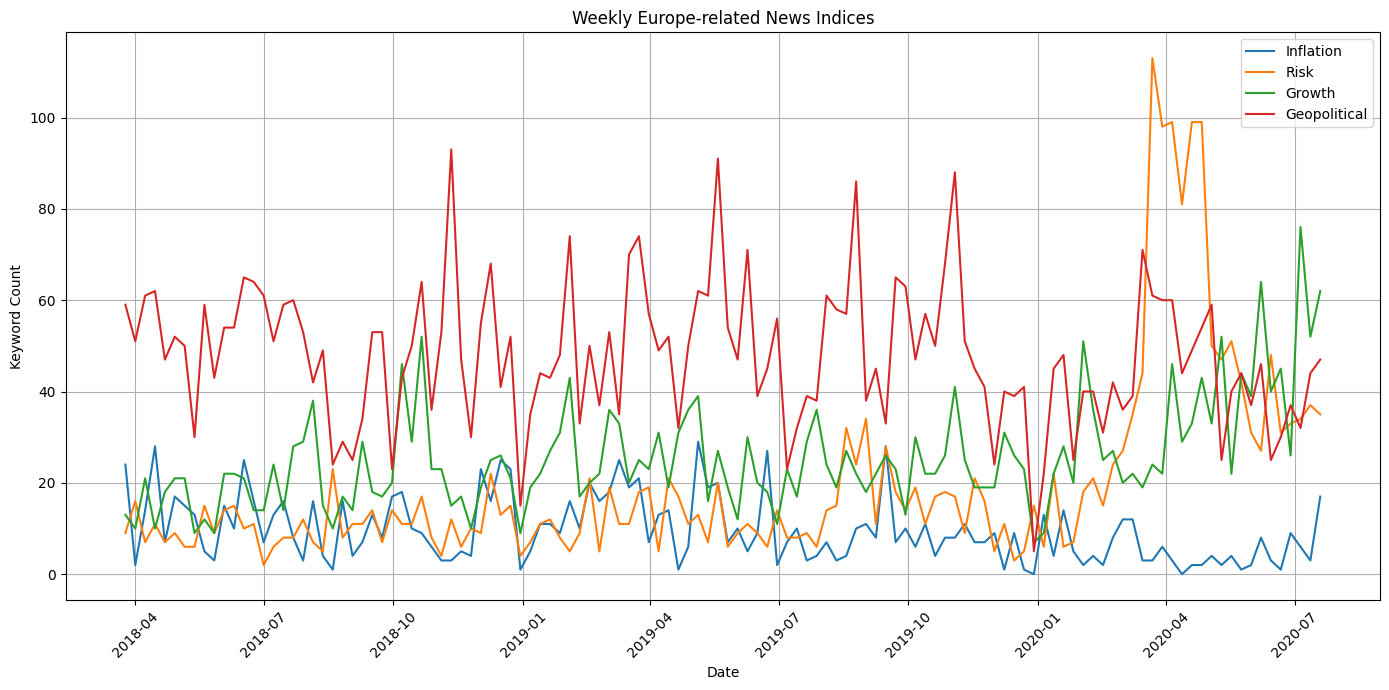

In [11]:
# --------------------------------------------------
# Agrégation hebdomadaire
# --------------------------------------------------

daily_reuters_indices["date"] = pd.to_datetime(daily_reuters_indices["date"])
daily_reuters_indices = daily_reuters_indices.set_index("date")
weekly_reuters_indices = daily_reuters_indices.resample("W").sum()

plt.figure(figsize=(14, 7))

plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["macro_inflation_index"], label="Inflation")
plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["macro_risk_index"], label="Risk")
plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["growth_index"], label="Growth")
plt.plot(weekly_reuters_indices.index, weekly_reuters_indices["geopolitical_index"], label="Geopolitical")

plt.title("Weekly Europe-related News Indices")
plt.xlabel("Date")
plt.ylabel("Keyword Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Test de différents modèles avec Reuters (partie 1)

### 3.1 Random Forest

#### 3.1.1 Préparation des données

In [12]:
# =========================================================
# 1. MERGE DES DONNEES (SPREAD + FEATURES NEWS)
# =========================================================

# On fusionne la direction du spread avec les indices news
data_reuters_final = spread[["direction"]].merge(
    daily_reuters_indices,
    left_index=True,
    right_index=True,
    how="inner"
)

# =========================================================
# 2. PREPARATION DES VARIABLES X ET y
# =========================================================

features = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

X = data_reuters_final[features]
y = data_reuters_final["direction"]

# =========================================================
# 3. TRAIN / TEST SPLIT (TEMPOREL)
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# =========================================================
# 4. MODELE RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.53      0.64      0.58        64
           1       0.42      0.32      0.37        53

    accuracy                           0.50       117
   macro avg       0.48      0.48      0.47       117
weighted avg       0.48      0.50      0.48       117



#### 3.1.2 Importance des features

geopolitical_index       0.331761
growth_index             0.268528
macro_inflation_index    0.201819
macro_risk_index         0.197892
dtype: float64


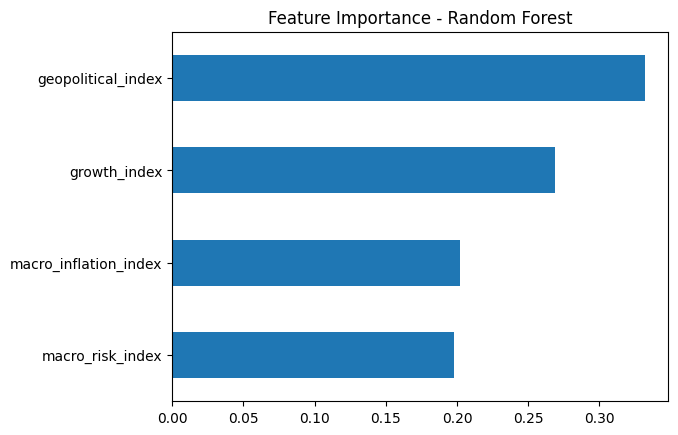

In [13]:
# =========================================================
# 5. IMPORTANCE DES FEATURES
# =========================================================

importance = pd.Series(
    model_rf.feature_importances_,
    index=features)

print(importance.sort_values(ascending=False))

# =========================================================
# 6. VISUALISATION DES IMPORTANCES
# =========================================================

plt.figure()
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.show()

#### 3.1.3 ROC Curve + AUC

AUC: 0.519310141509434


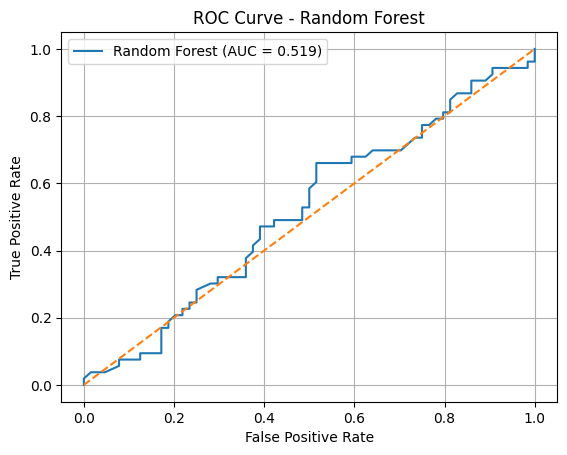

In [14]:
# =========================================================
# 7. ROC CURVE + AUC
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Probabilités (nécessaires pour ROC)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# AUC
auc_score = roc_auc_score(y_test, y_proba_rf)
print("AUC:", auc_score)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

La matrice de confusion montre des résultats très mauvais pour ce modèle RandomForest associé à ce jeu de données. 
L'accuracy vaut 50% en moyenne, ce qui traduit le fait que le modèle à le même pouvoir prédictif qu'une pièce de monnaie : beaucoup d'énergie pour si peu !
On note également que le modèle prédit plus correctement les baisses, peut-être parce que celle-ci sont moins bruitées... 

### 3.2 Logistic Regression

#### 3.2.1 Préparation des données

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PREPARATION DES VARIABLES X ET y
# =========================================================

features = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

X = data_reuters_final[features]
y = data_reuters_final["direction"]

# =========================================================
# 2. TRAIN / TEST SPLIT (TEMPOREL)
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

# =========================================================
# 3. STANDARDISATION (NECESSAIRE POUR LOGISTIC REGRESSION)
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 4. MODELE LOGISTIC REGRESSION
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

Logistic Regression
              precision    recall  f1-score   support

           0       0.56      0.41      0.47        97
           1       0.45      0.59      0.51        79

    accuracy                           0.49       176
   macro avg       0.50      0.50      0.49       176
weighted avg       0.51      0.49      0.49       176



#### 3.2.2 ROC Curve + AUC

AUC: 0.5373221975727522


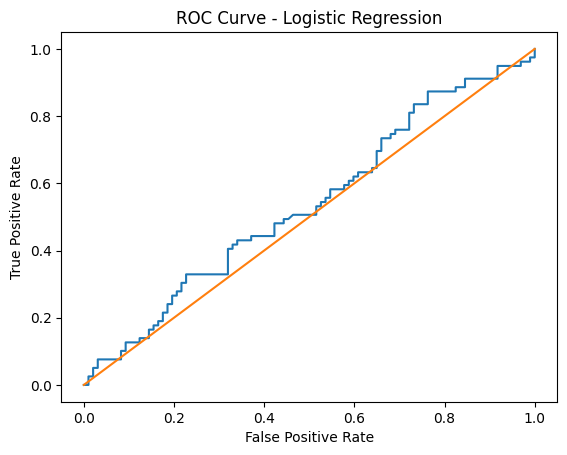

In [16]:
# =========================================================
# 5. EVALUATION : ROC CURVE + AUC
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_proba_log)
print("AUC:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

#### 3.2.3 Backtesting

Baseline accuracy: 0.5511363636363636
Model accuracy: 0.4943181818181818


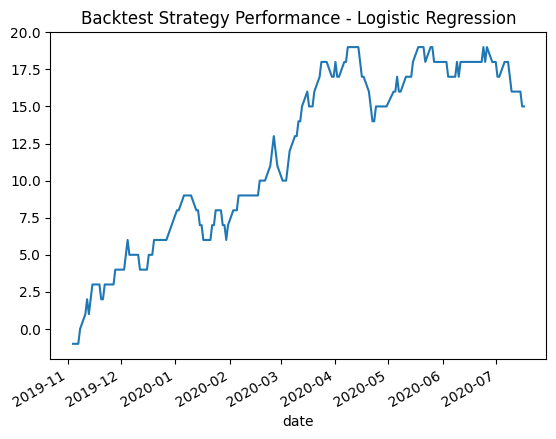

In [17]:
# =========================================================
# 6. BASELINE NAIF
# =========================================================

from sklearn.metrics import accuracy_score

y_baseline = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, y_baseline)
model_accuracy = accuracy_score(y_test, y_pred_log)

print("Baseline accuracy:", baseline_accuracy)
print("Model accuracy:", model_accuracy)

# =========================================================
# 7. BACKTEST SIMPLE
# =========================================================

# y_pred = 1 → spread monte
# y_pred = 0 → spread baisse

backtest = data_reuters_final.iloc[len(X_train):].copy()
backtest["pred"] = y_pred_log

backtest["strategy_return"] = (
    (backtest["pred"] * 2 - 1) * backtest["direction"]
)

backtest["cum_return"] = backtest["strategy_return"].cumsum()

plt.figure()
backtest["cum_return"].plot()
plt.title("Backtest Strategy Performance - Logistic Regression")
plt.show()

In [21]:
# =========================================================
# 7. MODELE LOGISTIC REGRESSION (BASELINE LINEAIRE)
# =========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

Logistic Regression
              precision    recall  f1-score   support

           0       0.56      0.41      0.47        97
           1       0.45      0.59      0.51        79

    accuracy                           0.49       176
   macro avg       0.50      0.50      0.49       176
weighted avg       0.51      0.49      0.49       176



CV scores: [0.48453608 0.59793814 0.50515464 0.45360825 0.56701031]
Mean accuracy: 0.5216494845360824


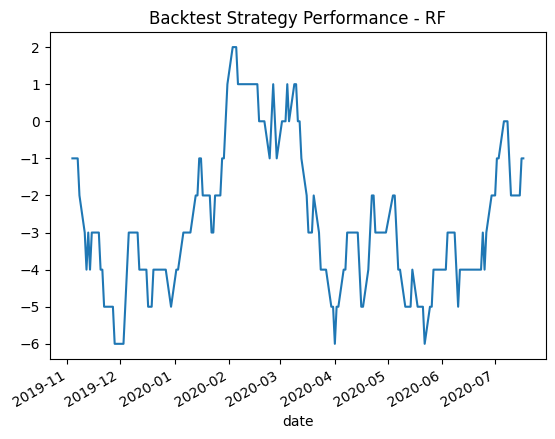

In [22]:
# =========================================================
# 8. CROSS-VALIDATION TIME SERIES
# =========================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=tscv)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

# =========================================================
# 9. BACKTEST SIMPLE
# =========================================================

# entraîner le modèle RF sur mon split actuel
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# backtest
backtest = data_reuters_final.loc[y_test.index].copy()
backtest["pred"] = y_pred_rf

backtest["strategy_return"] = (
    (backtest["pred"] * 2 - 1) * data_reuters_final.loc[backtest.index, "direction"]
)

backtest["cum_return"] = backtest["strategy_return"].cumsum()

plt.figure()
backtest["cum_return"].plot()
plt.title("Backtest Strategy Performance - RF")
plt.show()

AUC: 0.504893644786637


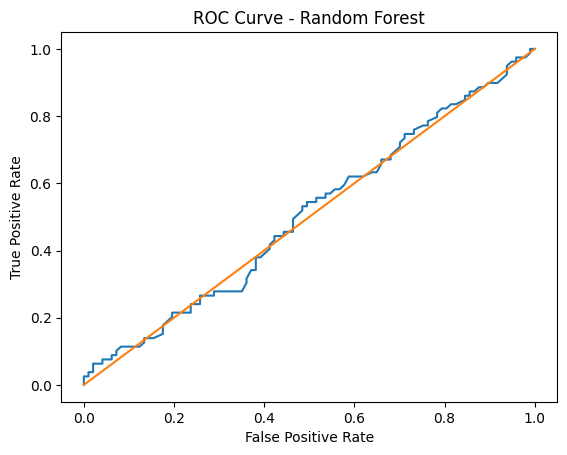

In [23]:
# =========================================================
# 10. ROC CURVE + AUC
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

rf_model.fit(X_train, y_train)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_proba_rf)
print("AUC:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

Baseline accuracy: 0.5511363636363636
Model accuracy: 0.5170454545454546


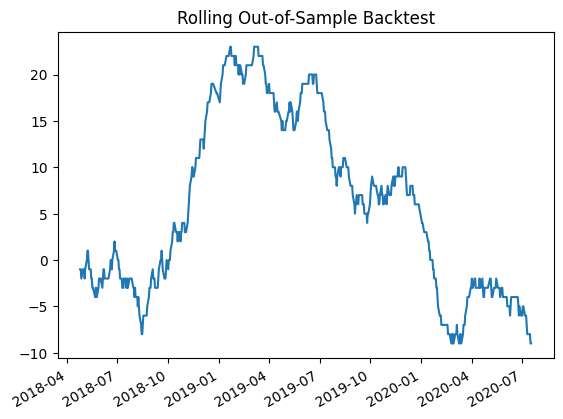

In [24]:
# =========================================================
# 11. BASELINE NAIF
# =========================================================

from sklearn.metrics import accuracy_score

y_baseline = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, y_baseline)
model_accuracy = accuracy_score(y_test, y_pred_rf)

print("Baseline accuracy:", baseline_accuracy)
print("Model accuracy:", model_accuracy)

# =========================================================
# 12. ROLLING OUT-OF-SAMPLE BACKTEST
# =========================================================

rolling_preds = []
rolling_real = []
rolling_dates = []

window_size = 24

for i in range(window_size, len(X)):
    
    X_train_roll = X.iloc[i-window_size:i]
    y_train_roll = y.iloc[i-window_size:i]
    
    X_test_roll = X.iloc[i:i+1]
    y_test_roll = y.iloc[i:i+1]
    
    model_roll = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    
    model_roll.fit(X_train_roll, y_train_roll)
    
    pred = model_roll.predict(X_test_roll)
    
    rolling_preds.append(pred[0])
    rolling_real.append(y_test_roll.values[0])
    rolling_dates.append(X.index[i])

rolling_df = pd.DataFrame({
    "real": rolling_real,
    "pred": rolling_preds
}, index=rolling_dates)

rolling_df["strategy_return"] = (
    (rolling_df["pred"] * 2 - 1) * rolling_df["real"]
)

rolling_df["cum_return"] = rolling_df["strategy_return"].cumsum()

plt.figure()
rolling_df["cum_return"].plot()
plt.title("Rolling Out-of-Sample Backtest")
plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       0.56      0.41      0.47        97
           1       0.45      0.59      0.51        79

    accuracy                           0.49       176
   macro avg       0.50      0.50      0.49       176
weighted avg       0.51      0.49      0.49       176

CV scores: [0.48453608 0.59793814 0.50515464 0.45360825 0.56701031]
Mean accuracy: 0.5216494845360824


/Users/marion/ml-news-spread/venv/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


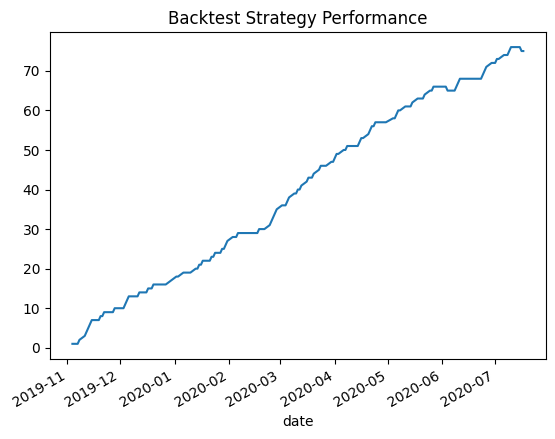

AUC: 0.5381051807386141


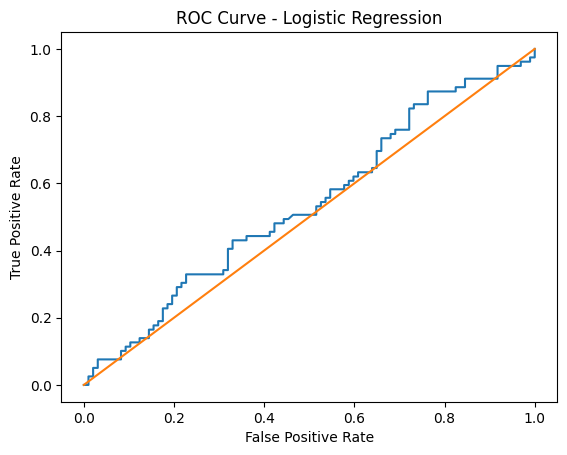

Baseline accuracy: 0.5511363636363636
Model Logistic accuracy: 0.4375


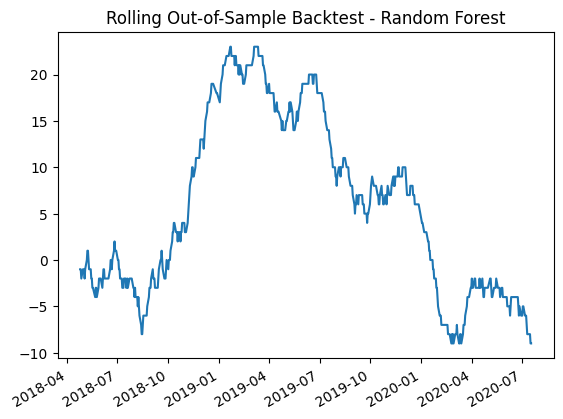

In [25]:
# =========================================================
# 7. MODELE LOGISTIC REGRESSION (BASELINE LINEAIRE)
# =========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

# =========================================================
# 8. CROSS-VALIDATION TIME SERIES
# =========================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=tscv)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

# =========================================================
# 9. BACKTEST SIMPLE
# =========================================================

y_pred_log = log_model.predict(X_test_scaled)

backtest = data_reuters_final.iloc[len(X_train):].copy()
backtest["pred"] = y_pred_log

backtest["strategy_return"] = (
    (backtest["pred"] * 2 - 1) * data_reuters_final.loc[backtest.index, "direction"]
)

backtest["cum_return"] = backtest["strategy_return"].cumsum()

plt.figure()
backtest["cum_return"].plot()
plt.title("Backtest Strategy Performance")
plt.show()

# =========================================================
# 10. ROC CURVE + AUC
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_proba_log = log_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_proba_log)
print("AUC:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# =========================================================
# 11. BASELINE NAIF
# =========================================================

from sklearn.metrics import accuracy_score

y_baseline = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, y_baseline)
model_accuracy = accuracy_score(y_test, y_pred_log)

print("Baseline accuracy:", baseline_accuracy)
print("Model Logistic accuracy:", model_accuracy)

# =========================================================
# 12. ROLLING OUT-OF-SAMPLE BACKTEST- RF
# =========================================================

rolling_preds = []
rolling_real = []
rolling_dates = []

window_size = 24

for i in range(window_size, len(X)):
    
    X_train_roll = X.iloc[i-window_size:i]
    y_train_roll = y.iloc[i-window_size:i]
    
    X_test_roll = X.iloc[i:i+1]
    y_test_roll = y.iloc[i:i+1]
    
    model_roll = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    
    model_roll.fit(X_train_roll, y_train_roll)
    
    pred = model_roll.predict(X_test_roll)
    
    rolling_preds.append(pred[0])
    rolling_real.append(y_test_roll.values[0])
    rolling_dates.append(X.index[i])

rolling_df = pd.DataFrame({
    "real": rolling_real,
    "pred": rolling_preds
}, index=rolling_dates)

rolling_df["strategy_return"] = (
    (rolling_df["pred"] * 2 - 1) * rolling_df["real"]
)

rolling_df["cum_return"] = rolling_df["strategy_return"].cumsum()

plt.figure()
rolling_df["cum_return"].plot()
plt.title("Rolling Out-of-Sample Backtest - Random Forest")
plt.show()

Le modèle de Regression Logistic est très légèrement meilleur, avec une accuracy de 54%. 

## 2. Construction des features news : françaises (partie 2)

### 2.2.1 Les echos

L'idée est ici de récupérer uniquement les news françaises, d'un quotien spécialisé en économie et en finance

In [26]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from urllib.parse import urljoin

BASE_URL = "https://www.lesechos.fr"
PAGE_URL = "https://www.lesechos.fr/"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

def get_html(url):
    r = requests.get(url, headers=HEADERS, timeout=15)
    r.raise_for_status()
    return r.text

def parse_articles(html, base_url=BASE_URL):
    soup = BeautifulSoup(html, "html.parser")
    rows = []

    # Essaie de repérer les balises article
    for article in soup.select("article"):
        title = None
        url = None
        date = None

        # lien + titre
        a = article.find("a", href=True)
        if a:
            url = urljoin(base_url, a["href"])

        # plusieurs options possibles pour le titre
        for selector in ["h1", "h2", "h3"]:
            tag = article.find(selector)
            if tag and tag.get_text(strip=True):
                title = tag.get_text(strip=True)
                break

        # balise time si présente
        time_tag = article.find("time")
        if time_tag:
            date = time_tag.get("datetime") or time_tag.get_text(strip=True)

        if title and url:
            rows.append({
                "title": title,
                "date": date,
                "url": url
            })

    return rows

def scrape_page(url):
    html = get_html(url)
    data = parse_articles(html)
    df = pd.DataFrame(data).drop_duplicates()
    return df

if __name__ == "__main__":
    PATH_DATA = "../data/"
    df = scrape_page(PAGE_URL)
    print(df.head(10))
    df.to_csv(PATH_DATA + "news_metadata.csv", index=False, encoding="utf-8-sig")
    print(f"{len(df)} articles sauvegardés dans news_metadata.csv")


# Cette méthode était prometteuse sur le papier, mais elle se heurte à la pratique car le site web du journal empêche le webscrapping, 
# donc les requêtes sont rapidement rejetées. 

                                               title  date  \
0  Pourquoi l'aide à domicile va coûter plus cher...  None   
1  Guerre au Moyen-Orient : Israël appelle des ha...  None   
2  Prix du carburant : Bercy lance un « prêt flas...  None   
3  La facture du Rafale F5 grimpe, Paris se tourn...  None   
4  ManoMano, Mirakl, Vestiaire Collective… le gra...  None   
5  « Elle est faite pour être numéro 1 » : Margue...  None   
6  « Les investisseurs demandent une nouvelle dyn...  None   
7  « Ça n'a fait que descendre, encore et encore ...  None   
8  Les leçons du chef d'état-major de la marine f...  None   
9  « Nous n'avions pas prévu une guerre de cette ...  None   

                                                 url  
0  https://www.lesechos.fr/economie-france/social...  
1  https://www.lesechos.fr/monde/afrique-moyen-or...  
2  https://www.lesechos.fr/economie-france/budget...  
3  https://www.lesechos.fr/industrie-services/air...  
4  https://www.lesechos.fr/start-up/next40

### 2.2.2 Le Monde
Nous avons également tenté d'utiliser le flux RSS du Monde

In [30]:
import feedparser
import pandas as pd

feed_url = "https://www.lemonde.fr/economie/rss_full.xml"
feed = feedparser.parse(feed_url)

rows = []
for entry in feed.entries:
    rows.append({
        "title": entry.get("title"),
        "published_at": entry.get("published"),
        "url": entry.get("link"),
        "summary": entry.get("summary")
    })

df = pd.DataFrame(rows)
print(df.head(25))

# Cependant, on ne peut avoir accès (gratuitement) qu'au 20 derniers articles


Empty DataFrame
Columns: []
Index: []


### 2.2.3 GDELT
Ce projet permet, dans le cadre d'un usage strictement privé, de webscapper un très grand nombre de titres de journaux, anglophones mais aussi internationaux (alors traduits en anglais). 2 niveaux de granularités sont proposés : toutes les 15 minutes, ou tous les jours. Nous avons choisi cette deuxième option puisque nous n'avons pas de données sur les spread intra-day.  
Le point négatif de cette méthode est d'une part la profondeur (limité quand on remonte dans le temps) et le temps pour récupérer les données. A titre d'information, pour récupérer les articles entre 2023 et 2024, il fallut plus de 300 minutes, soit 5 heures.

In [42]:
# import pandas as pd
# from datetime import datetime, timedelta

# # pip install gdeltdoc
# from gdeltdoc import GdeltDoc, Filters

# START_DATE = "2023-01-01"
# END_DATE   = "2026-03-28"

# gd = GdeltDoc()

# def date_range(start_date: str, end_date: str):
#     start = datetime.strptime(start_date, "%Y-%m-%d")
#     end = datetime.strptime(end_date, "%Y-%m-%d")
#     cur = start
#     while cur <= end:
#         yield cur
#         cur += timedelta(days=1)

# all_days = []

# for day in date_range(START_DATE, END_DATE):
#     time.sleep(6)
#     day_str = day.strftime("%Y-%m-%d")
#     next_day_str = (day + timedelta(days=1)).strftime("%Y-%m-%d")

#     try:
#         filters = Filters(
#             start_date=day_str,
#             end_date=next_day_str,
#             language="French"
#         )

#         articles = gd.article_search(filters)

#         if articles is None or len(articles) == 0:
#             print(f"{day_str} -> 0 article")
#             continue

#         articles["query_date"] = pd.to_datetime(day_str)
#         all_days.append(articles)

#         print(f"{day_str} -> {len(articles)} articles")

#     except Exception as e:
#         print(f"Erreur {day_str}: {e}")

# news_df = pd.concat(all_days, ignore_index=True) if all_days else pd.DataFrame()

# if not news_df.empty:
#     # nettoyage minimal
#     news_df["seendate"] = pd.to_datetime(news_df["seendate"], errors="coerce")
#     news_df["day"] = news_df["seendate"].dt.date

#     # garder seulement les colonnes utiles
#     cols = ["day", "seendate", "title", "url", "domain", "language", "sourcecountry"]
#     cols = [c for c in cols if c in news_df.columns]
#     news_df = news_df[cols].drop_duplicates()

# news_df.to_csv("gdelt_french_titles_2023_2026.csv", index=False, encoding="utf-8-sig")

# print(news_df.head())
# print(news_df.shape)

# daily_titles = (
#     news_df.groupby("day")
#     .agg(
#         n_articles=("title", "count"),
#         titles=("title", lambda x: " ||| ".join(x.dropna().astype(str)))
#     )
#     .reset_index()
# )

# daily_titles.to_csv("gdelt_french_titles_daily_2023_2026.csv", index=False, encoding="utf-8-sig")

# print(daily_titles.head())
# print(daily_titles.shape)

In [32]:
daily_titles_gdelt = pd.read_csv(PATH_DATA + "gdelt_french_titles_daily_2023_2026.csv")
daily_titles_gdelt.head(10)
# Dans la colonne titles, on trouve à la suite tous les titres chargés. 
# Les dates ne sont pas très regulières au début de l'échantillon, sans préjudice sur leur analyse

,day,n_articles,titles
0,2023-01-06,249,Boire un seul soda par jour peut augmenter le ...
1,2023-01-07,1,Brésil : le palais présidentiel en mauvais éta...
2,2023-01-14,245,Élection au Brésil : révélations compromettant...
3,2023-01-15,237,Paris et Berlin appellent lAfrique à condamner...
4,2023-01-16,13,LIran va bientôt recevoir des chasseurs russes...
5,2023-01-19,236,Chine : les transactions sur le marché des dev...
6,2023-01-20,14,Les pays occidentaux cherchent à freiner le dé...
7,2023-01-28,245,On a tout essayé : Guillaume Canet balance ...
8,2023-01-29,5,Le président français salue le rôle et le dyna...
9,2023-02-02,241,Miou - Miou mineure mais en couple avec Coluch...


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# =========================================================
# 1. PREPARATION DES DONNEES NEWS
# =========================================================

daily_titles_gdelt["day"] = pd.to_datetime(daily_titles_gdelt["day"], errors="coerce")
daily_titles_gdelt = daily_titles_gdelt.dropna(subset=["day"]).copy()
daily_titles_gdelt = daily_titles_gdelt.sort_values("day")
daily_titles_gdelt = daily_titles_gdelt[daily_titles_gdelt["day"] >= "2023-01-01"].copy()

daily_titles_gdelt["text"] = daily_titles_gdelt["titles"].fillna("").str.lower()

# =========================================================
# 2. FILTRE EUROPE
# =========================================================

europe_words = [
    "europe", "eu", "ue", "union européenne", "zone euro", "euro",
    "bce", "banque centrale européenne", "france", "allemagne",
    "italie", "espagne", "bruxelles", "paris", "berlin", "macron",
    "lagarde", "scholz", "bund"
]

def contains_any(text, words):
    return any(word in text for word in words)

daily_titles_gdelt["is_europe"] = daily_titles_gdelt["text"].apply(lambda x: contains_any(x, europe_words))
daily_titles_gdelt_europe = daily_titles_gdelt[daily_titles_gdelt["is_europe"]].copy()

# =========================================================
# 3. CONSTRUCTION DE PLUSIEURS FEATURES
# =========================================================

keyword_dict = {
    "inflation": [
        "inflation", "prix", "hausse des prix", "cpi", "ipc",
        "taux", "bce", "politique monétaire", "resserrement",
        "hausse de taux"
    ],
    "risk": [
        "crise", "récession", "dette", "déficit", "défaut",
        "risque", "prime de risque", "instabilité", "volatilité",
        "downgrade"
    ],
    "growth": [
        "croissance", "pib", "reprise", "expansion",
        "emploi", "chômage", "activité", "production"
    ],
    "geopolitical": [
        "guerre", "conflit", "sanctions", "gaz", "énergie",
        "pétrole", "ukraine", "russie", "tensions"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for feature_name, words in keyword_dict.items():
    daily_titles_gdelt_europe[f"{feature_name}_index"] = daily_titles_gdelt_europe["text"].apply(
        lambda x: count_keywords(x, words)
    )

feature_cols = [
    "inflation_index",
    "risk_index",
    "growth_index",
    "geopolitical_index"
]

# normalisation par volume d'articles
for col in feature_cols:
    daily_titles_gdelt_europe[col] = (
        daily_titles_gdelt_europe[col] / daily_titles_gdelt_europe["n_articles"].replace(0, 1)
    )

# feature bonus : volume de news
daily_titles_gdelt_europe["news_volume"] = daily_titles_gdelt_europe["n_articles"]
feature_cols = feature_cols + ["news_volume"]

# lissage léger pour réduire le bruit
for col in feature_cols:
    daily_titles_gdelt_europe[col] = daily_titles_gdelt_europe[col].rolling(7, min_periods=1).mean()

# on garde une base news propre
daily_titles_gdelt_europe = daily_titles_gdelt_europe[["day"] + feature_cols].copy()

# =========================================================
# 4. PREPARATION DES DONNEES DE SPREAD (CORRIGÉ)
# =========================================================

spread_europe = spread.reset_index()[["date", "fr_10y", "de_10y", "spread"]].copy()

spread_europe["date"] = pd.to_datetime(spread_europe["date"], errors="coerce")
spread_europe = spread_europe.dropna(subset=["date"])
spread_europe = spread_europe.sort_values("date")

# garder uniquement période cohérente
spread_europe = spread_europe[spread_europe["date"] >= "2023-01-01"].copy()

# =========================================================
# 5. CREATION DE data_final_europe
# =========================================================

data_final_europe = spread_europe.merge(
    daily_titles_gdelt_europe,
    left_on="date",
    right_on="day",
    how="left"
)

data_final_europe = data_final_europe.drop(columns=["day"])

# si certains jours n'ont pas de news, on met 0
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].fillna(0)

# =========================================================
# 6. CREATION DE LA TARGET
# =========================================================

data_final_europe = data_final_europe.sort_values("date").copy()

data_final_europe["delta"] = data_final_europe["spread"].diff()
data_final_europe["direction_t+1"] = (
    data_final_europe["spread"].diff().shift(-1) > 0
).astype(float)

# lag des features pour utiliser l'info de t pour prédire t+1
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].shift(1)

# vol simple si tu veux une variable de contrôle
data_final_europe["vol_1m"] = data_final_europe["spread"].rolling(20, min_periods=5).std()

# nettoyage final
data_final_europe = data_final_europe.dropna().copy()

## 3. Test de différents modèles avec les news françaises (partie 2)

### 3.1 Random forest 

In [34]:
# =========================================================
# 7. X ET y
# =========================================================

features = feature_cols + ["vol_1m"]

X = data_final_europe[features]
y = data_final_europe["direction_t+1"]

# =========================================================
# 8. TRAIN / TEST SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# =========================================================
# 9. STANDARDISATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 10. MODELE RANDOM FOREST
# =========================================================

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
model_rf.fit(X_train_scaled, y_train)

y_pred = model_rf.predict(X_test_scaled)
y_pred_proba = model_rf.predict_proba(X_test_scaled)[:, 1]


auc = roc_auc_score(y_test, y_pred_proba)
print("AUC =", auc)

# =========================================================
# 11. IMPORTANCE DES FEATURES
# =========================================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nImportance des features :")
print(feature_importance)

AUC = 0.5137310606060607

Importance des features :
              feature  importance
5              vol_1m    0.205816
0     inflation_index    0.190617
4         news_volume    0.170730
3  geopolitical_index    0.163641
2        growth_index    0.140359
1          risk_index    0.128836


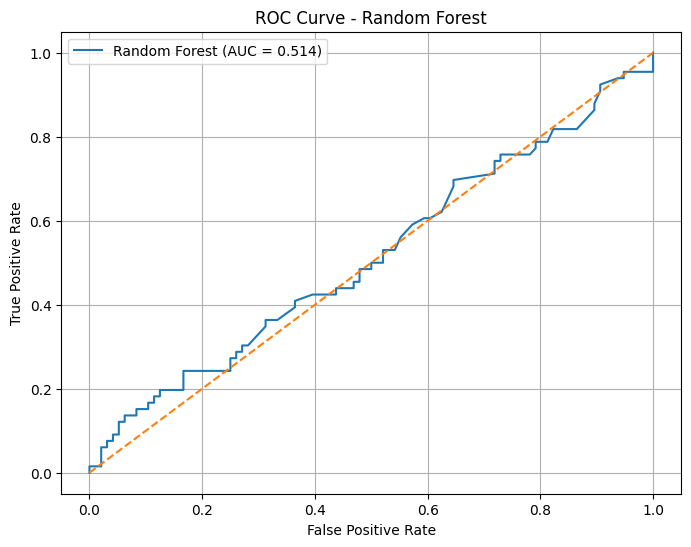

In [35]:
# =========================================================
# 12. ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# =========================================================
# 13. APERCU FINAL
# =========================================================

print("\nColonnes de data_final_europe :")
print(data_final_europe.columns.tolist())

print("\nAperçu :")
print(data_final_europe.head())

print("\nTaille finale :", data_final_europe.shape)
print("\nRépartition de y :")
print(y.value_counts(normalize=True))


Colonnes de data_final_europe :
['date', 'fr_10y', 'de_10y', 'spread', 'inflation_index', 'risk_index', 'growth_index', 'geopolitical_index', 'news_volume', 'delta', 'direction_t+1', 'vol_1m']

Aperçu :
        date  fr_10y  de_10y  spread  inflation_index  risk_index  \
4 2023-01-06    2.85    2.32    0.53         0.000000    0.000000   
5 2023-01-09    2.80    2.27    0.53         0.048193    0.032129   
6 2023-01-10    2.79    2.27    0.52         0.000000    0.000000   
7 2023-01-11    2.73    2.27    0.46         0.000000    0.000000   
8 2023-01-12    2.66    2.19    0.47         0.000000    0.000000   

   growth_index  geopolitical_index  news_volume         delta  direction_t+1  \
4       0.00000            0.000000          0.0  2.000000e-02            0.0   
5       0.02008            0.116466        249.0 -4.440892e-16            0.0   
6       0.00000            0.000000          0.0 -1.000000e-02            0.0   
7       0.00000            0.000000          0.0 -6.00000

## 4. Étude de la volatilité
Les résultats sur la prédiction des spread étant pour le moins peu éclairant, nous avons décidé de regarder si la volatilité était plus facile à prédire

RMSE = 0.011172790689346637
MAE  = 0.007910735852103303
R²   = -0.367182967330806

Coefficients Ridge :
           feature  coefficient
2  political_index     0.004144
1  sovereign_index     0.002271
3     stress_index    -0.001576
0   monetary_index    -0.001950


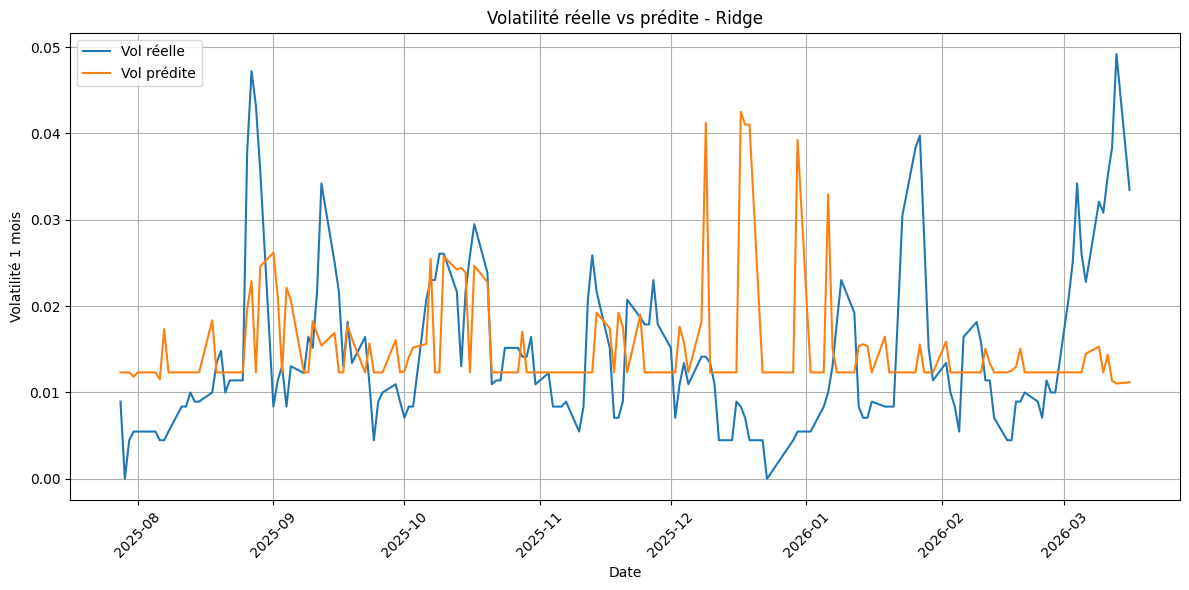


Colonnes de data_final_europe :
['date', 'fr_10y', 'de_10y', 'spread', 'monetary_index', 'sovereign_index', 'political_index', 'stress_index', 'delta', 'vol_1m']

Aperçu :
        date  fr_10y  de_10y  spread  monetary_index  sovereign_index  \
4 2023-01-12    2.66    2.19    0.47        0.000000              0.0   
5 2023-01-13    2.58    2.11    0.47        0.000000              0.0   
6 2023-01-16    2.69    2.21    0.48        0.000000              0.0   
7 2023-01-17    2.68    2.19    0.49        0.015193              0.0   
8 2023-01-18    2.55    2.09    0.46        0.000000              0.0   

   political_index  stress_index  delta    vol_1m  
4         0.000000      0.000000   0.01  0.034205  
5         0.000000      0.000000   0.00  0.032404  
6         0.000000      0.000000   0.01  0.023452  
7         0.064299      0.078687   0.01  0.011402  
8         0.000000      0.000000  -0.03  0.011402  

Taille finale : (801, 10)

Résumé de vol_1m :
count    8.010000e+02
mean   

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 1. PREPARATION DES DONNEES NEWS
# =========================================================

daily_titles_gdelt["day"] = pd.to_datetime(daily_titles_gdelt["day"], errors="coerce")
daily_titles_gdelt = daily_titles_gdelt.dropna(subset=["day"]).copy()
daily_titles_gdelt = daily_titles_gdelt.sort_values("day")
daily_titles_gdelt = daily_titles_gdelt[daily_titles_gdelt["day"] >= "2023-01-01"].copy()

daily_titles_gdelt["text"] = daily_titles_gdelt["titles"].fillna("").str.lower()

# =========================================================
# 2. FILTRE EUROPE
# =========================================================

europe_words = [
    "europe", "eu", "ue", "union européenne", "zone euro", "euro",
    "bce", "banque centrale européenne", "france", "allemagne",
    "italie", "espagne", "bruxelles", "paris", "berlin", "macron",
    "lagarde", "scholz", "bund"
]

def contains_any(text, words):
    return any(word in text for word in words)

daily_titles_gdelt["is_europe"] = daily_titles_gdelt["text"].apply(lambda x: contains_any(x, europe_words))
daily_titles_europe = daily_titles_gdelt[daily_titles_gdelt["is_europe"]].copy()

# =========================================================
# 3. CONSTRUCTION DES FEATURES NEWS
# =========================================================

keyword_dict = {
    "monetary": [
        "bce", "banque centrale", "taux", "taux directeur",
        "hausse de taux", "baisse de taux",
        "politique monétaire", "resserrement", "assouplissement",
        "inflation", "ipc"
    ],
    "sovereign": [
        "dette", "déficit", "notation", "downgrade",
        "agence de notation", "spread", "obligation",
        "finances publiques", "budget", "risque souverain"
    ],
    "political": [
        "gouvernement", "élection", "dissolution",
        "assemblée", "réforme", "vote",
        "majorité", "opposition", "crise politique"
    ],
    "stress": [
        "guerre", "conflit", "ukraine", "russie",
        "sanctions", "tensions", "crise",
        "énergie", "gaz", "pétrole"
    ]
}

def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

for feature_name, words in keyword_dict.items():
    daily_titles_europe[f"{feature_name}_index"] = daily_titles_europe["text"].apply(
        lambda x: count_keywords(x, words)
    )

feature_cols = [
    "monetary_index",
    "sovereign_index",
    "political_index",
    "stress_index"
]

# normalisation par volume d'articles
for col in feature_cols:
    daily_titles_europe[col] = (
        daily_titles_europe[col] / daily_titles_europe["n_articles"].replace(0, 1)
    )

# lissage léger
for col in feature_cols:
    daily_titles_europe[col] = daily_titles_europe[col].rolling(7, min_periods=1).mean()

daily_titles_europe = daily_titles_europe[["day"] + feature_cols].copy()

# =========================================================
# 4. PREPARATION DES DONNEES DE SPREAD
# =========================================================

spread_europe = data_final_europe[[
    "date", "fr_10y", "de_10y", "spread"
]].copy()

spread_europe["date"] = pd.to_datetime(spread_europe["date"], errors="coerce")
spread_europe = spread_europe.dropna(subset=["date"])
spread_europe = spread_europe.sort_values("date")
spread_europe = spread_europe[spread_europe["date"] >= "2023-01-01"].copy()

# =========================================================
# 5. CREATION DE data_final_europe
# =========================================================

data_final_europe = spread_europe.merge(
    daily_titles_europe,
    left_on="date",
    right_on="day",
    how="left"
)

data_final_europe = data_final_europe.drop(columns=["day"])

for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].fillna(0)

# =========================================================
# 6. CREATION DE LA VOLATILITE
# =========================================================

data_final_europe = data_final_europe.sort_values("date").copy()

data_final_europe["delta"] = data_final_europe["spread"].diff()
data_final_europe["vol_1m"] = data_final_europe["spread"].rolling(5, min_periods=5).std()

# lag des features
for col in feature_cols:
    data_final_europe[col] = data_final_europe[col].shift(1)

# nettoyage ciblé
data_final_europe = data_final_europe.dropna(subset=["vol_1m"]).copy()
data_final_europe = data_final_europe[data_final_europe["vol_1m"] > 0].copy()

# si besoin, décommente cette ligne pour être plus strict
# data_final_europe = data_final_europe.dropna(subset=feature_cols + ["vol_1m"]).copy()

# =========================================================
# 7. X ET y
# =========================================================

features = feature_cols
X = data_final_europe[features]
y = data_final_europe["vol_1m"]

# =========================================================
# 8. TRAIN / TEST SPLIT TEMPOREL
# =========================================================

split_idx = int(len(data_final_europe) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# =========================================================
# 9. STANDARDISATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 10. MODELE RIDGE
# =========================================================

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)

y_pred = model_ridge.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE =", rmse)
print("MAE  =", mae)
print("R²   =", r2)

# =========================================================
# 11. COEFFICIENTS
# =========================================================

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model_ridge.coef_
}).sort_values("coefficient", ascending=False)

print("\nCoefficients Ridge :")
print(coef_df)

# =========================================================
# 12. GRAPHE VALEURS REELLES VS PREDITES
# =========================================================

results = pd.DataFrame({
    "date": data_final_europe["date"].iloc[split_idx:],
    "vol_reelle": y_test.values,
    "vol_predite": y_pred
})

plt.figure(figsize=(12, 6))
plt.plot(results["date"], results["vol_reelle"], label="Vol réelle")
plt.plot(results["date"], results["vol_predite"], label="Vol prédite")
plt.xlabel("Date")
plt.ylabel("Volatilité 1 mois")
plt.title("Volatilité réelle vs prédite - Ridge")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 13. APERCU FINAL
# =========================================================

print("\nColonnes de data_final_europe :")
print(data_final_europe.columns.tolist())

print("\nAperçu :")
print(data_final_europe.head())

print("\nTaille finale :", data_final_europe.shape)
print("\nRésumé de vol_1m :")
print(data_final_europe["vol_1m"].describe())

## 5. exploration des réseaux de neuronnes

Dans ce projet très économique, les réseaux de neuronnes ne nous ont pas semblé être le coeur du sujet, dans la mesure où ils proposent des résultats difficilement interprétables, avec un effet "boite noire" qui ne correspond pas vraiment à l'analyse que nous voulions conduire. Néanmoins, nous avons fait unn petit test ci-dessous. 

### 5.1 Préparation des données

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. MERGE DES DONNEES (SPREAD + FEATURES NEWS)
# =========================================================

data_reuters_final = spread[["direction"]].merge(
    daily_reuters_indices,
    left_index=True,
    right_index=True,
    how="inner"
)

# =========================================================
# 2. PREPARATION DES VARIABLES X ET y
# =========================================================

features = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

X = data_reuters_final[features]
y = data_reuters_final["direction"]

# =========================================================
# 3. TRAIN / TEST SPLIT (TEMPOREL)
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

# =========================================================
# 4. STANDARDISATION (INDISPENSABLE POUR RESEAU DE NEURONES)
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================================
# 5. MODELE RESEAU DE NEURONES (MLP)
# =========================================================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

nn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),   # 2 couches cachées
    activation="relu",
    solver="adam",
    alpha=1e-4,                   # régularisation
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

nn_model.fit(X_train_scaled, y_train)

y_pred = nn_model.predict(X_test_scaled)

print("Neural Network (MLPClassifier)")
print(classification_report(y_test, y_pred))

Neural Network (MLPClassifier)
              precision    recall  f1-score   support

           0       0.57      0.81      0.67        97
           1       0.53      0.25      0.34        79

    accuracy                           0.56       176
   macro avg       0.55      0.53      0.51       176
weighted avg       0.55      0.56      0.52       176



### 5.2 Importance des variables

Permutation importance:
macro_risk_index         0.035985
geopolitical_index       0.010038
macro_inflation_index   -0.005492
growth_index            -0.007765
dtype: float64


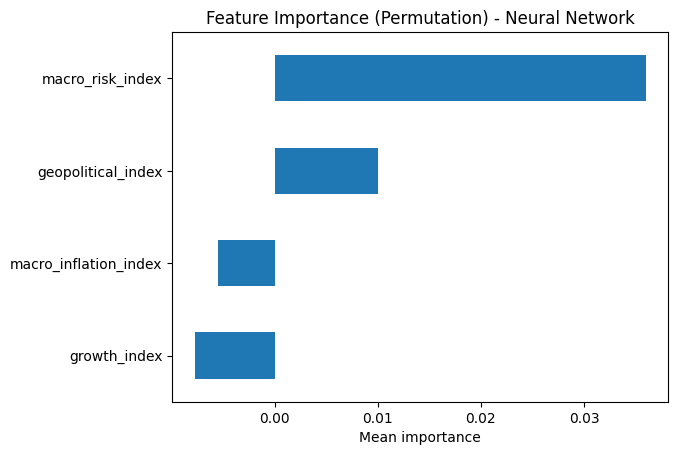

In [48]:
# =========================================================
# 6. IMPORTANCE APPROXIMATIVE DES VARIABLES
#    (via permutation importance)
# =========================================================

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    nn_model,
    X_test_scaled,
    y_test,
    n_repeats=30,
    random_state=42
)

importance = pd.Series(
    perm_importance.importances_mean,
    index=features
).sort_values(ascending=False)

print("Permutation importance:")
print(importance)

plt.figure()
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Permutation) - Neural Network")
plt.xlabel("Mean importance")
plt.show()

### 5.3 ROC Curve + AUC

AUC: 0.5571577711079212


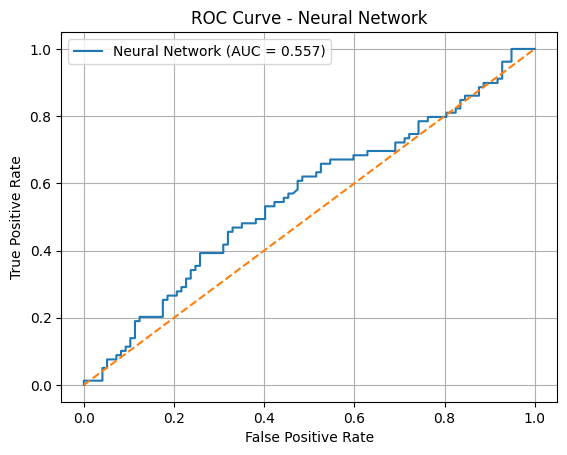

In [49]:
# =========================================================
# 7. ROC CURVE + AUC
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_proba = nn_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_proba)
print("AUC:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"Neural Network (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.grid(True)
plt.show()



Le ROC n'est pas si mauvais (enfin si on se réfère aux premiers essais de ce projet) ! L'accuracy moyenne est de 56%, et le déséquilibre qui conduit à prévoir mieux les 0 que les 1 semble ici en partie corrigés. Cependant, le graphique du ROC nous montre que ce n'est quand même pas la panacée...

Conclusion : 
Après cette étude, on constate que l'on n'a pas trouvé la recette miracle pour prévoir la direction du spread ni le niveau de volatilité. Ce n'est pas complétement surprenant, dans la mesure où ces variables financières sont très bruitées et dépendantes de très nombreux facteurs. 
Cependant, nous avons pratiqué le Machine Learning, testé dans un cadre nouveau les méthodes et les fonctions découvertes en classe, ce qui est déjà pas mal ! 

Merci !!

Marion & Maxence 